# KECG - Entity Alignment on DBP15K

> **Semi-supervised Entity Alignment via Joint Knowledge Embedding Model and Cross-graph Model**
> Chengjiang Li, Yixin Cao, Lei Hou, Jiaxin Shi, Juanzi Li, Tat-Seng Chua (*EMNLP 2019*)
> Source: https://aclanthology.org/D19-1274.pdf

A **self-contained** notebook (it imports nothing from an external package): the whole engine
is defined in the cells below. The same implementation is available in the `code/` package
(`code/src/models/kecg.py`, class `KECGTrainer` in `code/src/trainer.py`).

## The KECG idea
KECG jointly trains two models that share the **same entity embedding table**:

1. **Cross-Graph model (CG)**: a multi-head Graph Attention Network (GAT) with diagonal weights
   applied to a **combined graph** of both KGs. The GAT transfers local structure. The GAT
   output representations are pulled together for the pre-aligned entities with a triplet loss
   (and nearest-neighbour hard negatives).
2. **Knowledge Embedding model (KE)**: a TransE-style formulation `||h + r - t||` that models
   the specific relations and acts as a structural regulariser. Importantly, this loss is
   applied to the **GAT outputs**, which guides the GNN propagation.

Training alternates between the two objectives (CG on even epochs, KE on odd epochs).

## Key ingredients found to match the paper (see the Notes section)
- **The original TransE math bug**: the original source code normalises the L2 error vector and
  sums its components `sum(normalize(h+r-t))` instead of taking the true Euclidean distance.
  This behaviour has to be reproduced to obtain the exact metrics.
- **TransE applied to the GNN representations**: unlike plain GNNs, applying TransE to the GNN
  outputs instead of the initial embeddings strongly shapes the GAT attention matrices.
- **Global batch size for KE**: the paper uses the full 165k triples for a single KE step
  rather than aggressive mini-batching.
- **InstanceNorm1d disabled**: although useful in other settings, it over-smooths the features
  here and lowers the peak Hit@1.

## Results (DBP15K zh_en, 30% seed)
| | Hit@1 | Hit@5 | Hit@10 | MRR |
|---|---:|---:|---:|---:|
| **This notebook** | ~0.47 | ~0.75 | ~0.83 | ~0.59 |
| KECG (paper) | 0.477 | - | 0.835 | 0.598 |

## Metrics: **MRR, Hit@1, Hit@5, Hit@10** (+ CSLS).

---
## 1. Environment, imports and style

In [18]:
import os, sys, csv, time, random, logging, math
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field
from collections import Counter

import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm          # plain terminal tqdm (not the notebook widget)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("CUDA         :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2024
set_seed(SEED)
torch.backends.cudnn.benchmark = True

Project root : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k
PyTorch      : 2.5.1+cu121
CUDA         : True | NVIDIA GeForce RTX 3090


### 1.1 Modern dark theme (identical to `code/src/utils/plotting.py`)

In [19]:
"""Modern dark-theme plotting helpers.

A single :func:`set_modern_dark_style` configures Matplotlib with a clean,
GitHub-dark-inspired palette so every figure (training curves, EDA, metrics)
shares a consistent, modern look. The plotting functions below are used by the
trainer and can be reused from the notebook.
"""


# GitHub-dark-inspired palette
BG = "#0d1117"
PANEL = "#161b22"
GRID = "#21262d"
EDGE = "#30363d"
FG = "#c9d1d9"
TITLE = "#e6edf3"
MUTED = "#8b949e"
CYCLE = ["#58a6ff", "#3fb950", "#f778ba", "#ffa657", "#a371f7", "#56d4dd", "#e3b341"]


def set_modern_dark_style():
    """Apply the modern dark theme globally (idempotent)."""
    mpl.rcParams.update({
        "figure.facecolor": BG,
        "figure.edgecolor": BG,
        "savefig.facecolor": BG,
        "savefig.edgecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": EDGE,
        "axes.labelcolor": FG,
        "axes.titlecolor": TITLE,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.linewidth": 1.0,
        "grid.color": GRID,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "text.color": FG,
        "legend.facecolor": PANEL,
        "legend.edgecolor": EDGE,
        "legend.framealpha": 0.9,
        "lines.linewidth": 2.2,
        "lines.markersize": 5,
        "lines.solid_capstyle": "round",
        "font.size": 11,
        "figure.dpi": 120,
        "axes.prop_cycle": mpl.cycler(color=CYCLE),
    })


def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Apply consistent spine/tick styling to an Axes."""
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)
    return ax


def plot_loss_curves(loss_hist, ax=None, keys=("loss", "kge", "align", "pseudo")):
    """Plot per-epoch loss components from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in loss_hist]
    labels = {"loss": "total", "kge": "kge (TransE)",
              "align": "align (seed)", "pseudo": "align (pseudo)"}
    for key in keys:
        ax.plot(ep, [h.get(key, 0.0) for h in loss_hist], label=labels.get(key, key))
    ax.legend()
    return style_axes(ax, "Training loss", "epoch", "loss")


def plot_metric_curves(metric_hist, ax=None):
    """Plot per-eval metric history from a list of dicts (with 'epoch')."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ep = [h["epoch"] for h in metric_hist]
    for key in [k for k in metric_hist[0] if k != "epoch"]:
        ax.plot(ep, [h[key] for h in metric_hist], marker="o", label=key)
    ax.set_ylim(0, 1)
    ax.legend()
    return style_axes(ax, "Test metrics (avg direction)", "epoch", "score")

set_modern_dark_style()
print('Dark theme applique.')

Dark theme applique.


---
## 2. Configuration (YAML) and logging
Driven by **`configs/kecg_dbp15k.yaml`**. Code identical to `code/src/utils/config.py` and `logger.py`.

In [20]:
"""Configuration loading and run-directory bootstrap.

The whole experiment is driven by a single YAML file (see ``configs/``).
This module:
  * loads that YAML into a dotted-access namespace (``cfg.train.lr`` etc.),
  * creates a timestamped *run directory* under ``logging.output_dir``,
  * dumps the resolved config back to disk for reproducibility.

The logger is created separately by :mod:`src.utils.logger`.
"""




class Cfg(dict):
    """A ``dict`` that also supports attribute access, recursively.

    ``cfg.train.lr`` is equivalent to ``cfg["train"]["lr"]``. This keeps the
    code readable while still being a plain dict underneath (so it serialises
    straight back to YAML/JSON).
    """

    def __init__(self, d: dict | None = None):
        super().__init__()
        for k, v in (d or {}).items():
            self[k] = Cfg(v) if isinstance(v, dict) else v

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError as e:
            raise AttributeError(name) from e

    def __setattr__(self, name, value):
        self[name] = Cfg(value) if isinstance(value, dict) and not isinstance(value, Cfg) else value

    def to_plain(self):
        """Convert back to nested plain dicts (for YAML/JSON dumping)."""
        return {k: (v.to_plain() if isinstance(v, Cfg) else v) for k, v in self.items()}


def load_config(path: str | Path, project_root: str | Path | None = None) -> Cfg:
    """Load a YAML config file into a :class:`Cfg` namespace.

    ``project_root`` (defaults to the parent of ``configs/``) is recorded so
    relative data/output paths can be resolved consistently regardless of the
    current working directory.
    """
    path = Path(path).resolve()
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    cfg = Cfg(raw)
    root = Path(project_root).resolve() if project_root else path.parent.parent
    cfg._project_root = str(root)
    cfg._config_path = str(path)
    return cfg


def make_run_dir(cfg: Cfg) -> Path:
    """Create (and return) the timestamped run directory for this experiment.

    Layout::

        <output_dir>/<experiment.name>_<YYYYmmdd-HHMMSS>/
            training.txt          (full training log)
            config_used.yaml      (snapshot of the resolved config)
            model.pt / model_best.pt
            embeddings.pt
            metrics.csv / loss.csv
            *.png                 (loss & metric curves)
    """
    root = Path(cfg._project_root)
    out = root / cfg.logging.output_dir
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = out / f"{cfg.experiment.name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    cfg._run_dir = str(run_dir)

    # snapshot the exact config used for this run
    with open(run_dir / cfg.logging.config_dump, "w", encoding="utf-8") as f:
        yaml.safe_dump(cfg.to_plain(), f, sort_keys=False, allow_unicode=True)
    return run_dir

In [21]:
"""Logging setup: write simultaneously to the console and to ``training.txt``."""




def get_logger(cfg: Cfg, run_dir: Path) -> logging.Logger:
    """Return a logger writing to both stdout and ``training.txt``.

    Re-callable safely (handlers are reset) so re-running the setup does not
    duplicate every log line.
    """
    logger = logging.getLogger(cfg.experiment.name)
    logger.setLevel(getattr(logging, cfg.logging.log_level.upper(), logging.INFO))
    logger.handlers.clear()
    logger.propagate = False

    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

    fh = logging.FileHandler(run_dir / cfg.logging.log_file, mode="w", encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    return logger

In [22]:
cfg = load_config(PROJECT_ROOT / "configs" / "kecg_dbp15k.yaml", project_root=PROJECT_ROOT)
cfg.experiment.seed = SEED
cfg.experiment.name = f"kecg_{cfg.data.lang}_{cfg.data.fold}_nb"

run_dir = make_run_dir(cfg)
logger = get_logger(cfg, run_dir)
device = torch.device(cfg.experiment.device if torch.cuda.is_available() else "cpu")
logger.info(f"Run dir : {run_dir}")
logger.info(f"Device  : {device}")
print(yaml.safe_dump(cfg.to_plain(), sort_keys=False, allow_unicode=True))

03:40:07 | INFO    | Run dir : /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/kecg_zh_en_0_3_nb_20260531-034007
03:40:07 | INFO    | Device  : cuda
experiment:
  name: kecg_zh_en_0_3_nb
  model: kecg
  seed: 2024
  device: cuda
data:
  root: Data/dbp15k
  lang: zh_en
  fold: '0_3'
  use_mtranse_format: true
model:
  embed_dim: 128
  n_layers: 2
  n_heads: 2
  attn_dropout: 0.0
  normalize_embeddings: false
train:
  epochs: 3000
  lr: 0.005
  optimizer: adagrad
  weight_decay: 0.0
  grad_clip: 0.0
  early_stop_patience: 12
  margin_cg: 3.0
  margin_ke: 3.0
  k_cg: 25
  k_ke: 2
  use_nns: true
  update_num: 5
  ke_batch_size: 200000
eval:
  every: 25
  hits_at:
  - 1
  - 5
  - 10
  metric: l2
  csls_k: 3
  eval_chunk: 1024
  direction: both
logging:
  output_dir: experiments
  log_file: training.txt
  config_dump: config_used.yaml
  save_best: true
  save_last: true
  checkpoint_name: model.pt
  embeddings_name: embeddings.pt
  metrics_csv: metrics.csv
  loss_csv: loss.

---
## 3. DBP15K data and graph construction

JAPE/MTransE format (disjoint contiguous ids). Code identical to `code/src/data.py` (includes
KECG's graph builder: combined undirected graph + self-loops).

In [23]:
"""DBP15K data loading + neighbourhood construction for NAEA.

Data layout (the clean JAPE / MTransE split we use, ``<lang>/mtranse/<fold>/``):

    ent_ids_1 / ent_ids_2 : "<id>\\t<uri>"   entities of KG1 (e.g. zh) / KG2 (en)
    rel_ids_1 / rel_ids_2 : "<id>\\t<uri>"   relations of KG1 / KG2
    triples_1 / triples_2 : "<h>\\t<r>\\t<t>"
    sup_pairs             : "<e1>\\t<e2>"    seed (training) alignments  (30% for 0_3)
    ref_pairs             : "<e1>\\t<e2>"    test alignments             (70% for 0_3)

Crucially, in this split the entity ids of KG1 and KG2 are **disjoint** and form
a single contiguous range ``0 .. num_entities-1``; likewise relation ids. That
lets us use one shared embedding table and index it directly.
"""




# --------------------------------------------------------------------------- #
#  Raw file readers
# --------------------------------------------------------------------------- #
def _read_id_uri(path: Path) -> dict[int, str]:
    d = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                d[int(parts[0])] = parts[1]
    return d


def _read_triples(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 3:
                rows.append((int(p[0]), int(p[1]), int(p[2])))
    return np.asarray(rows, dtype=np.int64)


def _read_pairs(path: Path) -> np.ndarray:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.rstrip("\n").split("\t")
            if len(p) >= 2:
                rows.append((int(p[0]), int(p[1])))
    return np.asarray(rows, dtype=np.int64)


# --------------------------------------------------------------------------- #
#  Container
# --------------------------------------------------------------------------- #
@dataclass
class DBP15K:
    """Everything the model/trainer needs, as numpy arrays + lookup dicts."""

    lang: str
    fold: str
    ent_uri: dict[int, str]            # global entity id -> uri
    rel_uri: dict[int, str]            # global relation id -> uri
    kg1_ents: np.ndarray               # entity ids belonging to KG1
    kg2_ents: np.ndarray               # entity ids belonging to KG2
    triples1: np.ndarray               # (M1, 3)  KG1 triples
    triples2: np.ndarray               # (M2, 3)  KG2 triples
    train_pairs: np.ndarray            # (S, 2)   seed alignments
    test_pairs: np.ndarray             # (T, 2)   test alignments
    num_entities: int = field(init=False)
    num_relations: int = field(init=False)

    def __post_init__(self):
        self.num_entities = int(max(self.ent_uri) + 1)
        self.num_relations = int(max(self.rel_uri) + 1)

    @property
    def triples(self) -> np.ndarray:
        return np.concatenate([self.triples1, self.triples2], axis=0)

    def summary(self) -> dict:
        return {
            "lang": self.lang,
            "fold": self.fold,
            "num_entities": self.num_entities,
            "num_relations": self.num_relations,
            "|KG1 ents|": len(self.kg1_ents),
            "|KG2 ents|": len(self.kg2_ents),
            "|KG1 triples|": len(self.triples1),
            "|KG2 triples|": len(self.triples2),
            "train_pairs": len(self.train_pairs),
            "test_pairs": len(self.test_pairs),
        }


def load_dbp15k(root: str | Path, lang: str, fold: str, use_mtranse: bool = True) -> DBP15K:
    base = Path(root) / lang / "mtranse" / fold if use_mtranse else Path(root) / lang / fold

    ent1 = _read_id_uri(base / "ent_ids_1")
    ent2 = _read_id_uri(base / "ent_ids_2")
    rel1 = _read_id_uri(base / "rel_ids_1")
    rel2 = _read_id_uri(base / "rel_ids_2")

    ent_uri = {**ent1, **ent2}
    rel_uri = {**rel1, **rel2}

    triples1 = _read_triples(base / "triples_1")
    triples2 = _read_triples(base / "triples_2")

    pair_train = "sup_pairs" if use_mtranse else "sup_ent_ids"
    pair_test = "ref_pairs" if use_mtranse else "ref_ent_ids"
    train_pairs = _read_pairs(base / pair_train)
    test_pairs = _read_pairs(base / pair_test)

    return DBP15K(
        lang=lang,
        fold=fold,
        ent_uri=ent_uri,
        rel_uri=rel_uri,
        kg1_ents=np.asarray(sorted(ent1), dtype=np.int64),
        kg2_ents=np.asarray(sorted(ent2), dtype=np.int64),
        triples1=triples1,
        triples2=triples2,
        train_pairs=train_pairs,
        test_pairs=test_pairs,
    )


# --------------------------------------------------------------------------- #
#  Neighbourhood construction
# --------------------------------------------------------------------------- #
def build_neighbors(data: DBP15K, max_neighbors: int, seed: int = 0):
    """Build padded neighbour tensors for the attention aggregator.

    For every entity ``e`` we collect its neighbours from all triples it
    participates in. A neighbour is a *(relation, entity, direction)* triplet:

      * out-edge ``(e, r, t)``  ->  neighbour ``t`` via ``r``, sign = -1
        (TransE: ``e ~= t - r``, so the message that reconstructs ``e`` is ``t - r``)
      * in-edge  ``(h, r, e)``  ->  neighbour ``h`` via ``r``, sign = +1
        (TransE: ``e ~= h + r``, message ``h + r``)

    Entities with more than ``max_neighbors`` neighbours are randomly
    sub-sampled; entities with fewer are zero-padded and masked.

    Returns four ``LongTensor``/``Tensor``/``BoolTensor`` of shape
    ``(num_entities, max_neighbors)``: ``(neigh_ent, neigh_rel, neigh_sign, mask)``.
    """
    rng = random.Random(seed)
    N = data.num_entities
    adj: list[list[tuple[int, int, int]]] = [[] for _ in range(N)]

    for arr in (data.triples1, data.triples2):
        for h, r, t in arr:
            adj[h].append((int(r), int(t), -1))   # out-edge:  e=h, message t - r
            adj[t].append((int(r), int(h), +1))   # in-edge:   e=t, message h + r

    K = max_neighbors
    neigh_ent = np.zeros((N, K), dtype=np.int64)
    neigh_rel = np.zeros((N, K), dtype=np.int64)
    neigh_sign = np.zeros((N, K), dtype=np.float32)
    mask = np.zeros((N, K), dtype=bool)

    for e in range(N):
        nbrs = adj[e]
        if len(nbrs) > K:
            nbrs = rng.sample(nbrs, K)
        for j, (r, ne, s) in enumerate(nbrs):
            neigh_rel[e, j] = r
            neigh_ent[e, j] = ne
            neigh_sign[e, j] = s
            mask[e, j] = True

    return (
        torch.from_numpy(neigh_ent),
        torch.from_numpy(neigh_rel),
        torch.from_numpy(neigh_sign),
        torch.from_numpy(mask),
    )


# --------------------------------------------------------------------------- #
#  Negative sampling helpers
# --------------------------------------------------------------------------- #
class TripleSampler:
    """Mini-batch iterator over triples with per-KG corrupted negatives.

    Negatives are produced by replacing the head *or* the tail with a uniformly
    random entity **from the same KG** (cross-KG corruptions would be trivial
    negatives and pollute the signal).
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        t1 = torch.from_numpy(data.triples1)
        t2 = torch.from_numpy(data.triples2)
        kg = torch.cat([torch.zeros(len(t1), dtype=torch.long),
                        torch.ones(len(t2), dtype=torch.long)])
        self.triples = torch.cat([t1, t2], 0).to(device)        # (M,3)
        self.kg = kg.to(device)                                  # (M,)
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, kg_flags: torch.Tensor) -> torch.Tensor:
        """A random entity from the same KG as each row of ``kg_flags``."""
        n = kg_flags.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg_flags == 0, r1, r2)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                              # (B,3)
            kg = self.kg[idx]                                    # (B,)
            B = pos.shape[0]
            # repeat for `neg` corruptions
            pos_r = pos.repeat(self.neg, 1)                      # (B*neg,3)
            kg_r = kg.repeat(self.neg)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * self.neg, device=self.device) < 0.5
            rnd = self._rand_same_kg(kg_r)
            neg[:, 0] = torch.where(corrupt_head, rnd, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, rnd, neg[:, 2])
            yield pos, neg, kg


class AlignSampler:
    """Mini-batch iterator over alignment pairs with corrupted negatives.

    For a positive pair ``(e1, e2)`` we corrupt the right side (a KG2 entity)
    and the left side (a KG1 entity) to obtain negatives in both alignment
    directions. ``set_pairs`` lets the trainer inject bootstrapped pseudo-pairs.

    **Hard (nearest-neighbour) negatives.** If ``set_hard_negatives`` has been
    called, negatives are drawn from each pair's pre-computed nearest cross-KG
    candidates (the *confusable* entities) instead of uniformly at random - the
    epsilon-truncated negative sampling of BootEA/NAEA, which sharpens Hit@1. Any
    candidate that equals the gold target is replaced by a random one.
    """

    def __init__(self, data: DBP15K, device, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(device)
        self.hard_r = None          # (S, C) nearest KG2 candidates per pair (corrupt right)
        self.hard_l = None          # (S, C) nearest KG1 candidates per pair (corrupt left)
        self.set_pairs(data.train_pairs)

    def set_pairs(self, pairs):
        if isinstance(pairs, np.ndarray):
            pairs = torch.from_numpy(pairs)
        self.pairs = pairs.to(self.device).long()
        self.hard_r = self.hard_l = None    # invalidate stale hard-negative tables

    def set_hard_negatives(self, hard_r, hard_l):
        """``hard_r``/``hard_l``: (S, C) LongTensors aligned with ``self.pairs``."""
        self.hard_r = hard_r.to(self.device)
        self.hard_l = hard_l.to(self.device)

    def __len__(self):
        return len(self.pairs)

    def _sample_hard(self, table, rows, n, gold):
        """Pick ``n`` candidates per row from ``table[rows]``, avoiding ``gold``."""
        cand = table[rows]                                       # (B, C)
        C = cand.shape[1]
        sel = torch.randint(C, (cand.shape[0], n), device=self.device)
        out = torch.gather(cand, 1, sel).reshape(-1)            # (B*n,)
        # replace any accidental gold hit with a random entity from the same KG
        pool = self.kg2_ents if table is self.hard_r else self.kg1_ents
        clash = out == gold
        if clash.any():
            out[clash] = pool[torch.randint(len(pool), (int(clash.sum()),), device=self.device)]
        return out

    def batches(self, batch_size: int, shuffle: bool = True):
        S = len(self.pairs)
        order = torch.randperm(S, device=self.device) if shuffle else torch.arange(S, device=self.device)
        for s in range(0, S, batch_size):
            idx = order[s:s + batch_size]
            pos = self.pairs[idx]                                # (B,2)
            B = pos.shape[0]
            n = self.neg
            e1 = pos[:, 0].repeat_interleave(n)
            e2 = pos[:, 1].repeat_interleave(n)
            if self.hard_r is not None and self.hard_l is not None:
                neg_r = self._sample_hard(self.hard_r, idx, n, e2)
                neg_l = self._sample_hard(self.hard_l, idx, n, e1)
            else:
                neg_r = self.kg2_ents[torch.randint(len(self.kg2_ents), (B * n,), device=self.device)]
                neg_l = self.kg1_ents[torch.randint(len(self.kg1_ents), (B * n,), device=self.device)]
            yield pos, (e1, e2, neg_l, neg_r)


# =========================================================================== #
#  BootEA-specific helpers : alignment-by-swapping + dynamic triple sampling
# =========================================================================== #
def kg_of_entity(data: "DBP15K") -> np.ndarray:
    """Return an array ``kg[e] in {0, 1}`` giving the KG each entity belongs to."""
    kg = np.zeros(data.num_entities, dtype=np.int64)
    kg[data.kg2_ents] = 1
    return kg


class Swapper:
    """Generate BootEA *aligned triples* by swapping labelled entities.

    For a labelled pair ``(a, b)`` we substitute ``b`` for ``a`` in each of
    ``a``'s triples and vice-versa, e.g. ``(a, r, t) -> (b, r, t)``. The swapped
    entities then share relational contexts, which pulls their embeddings
    together - BootEA's core alignment mechanism.

    Per-entity triple lists are precomputed once; :meth:`generate` is then cheap
    enough to be re-run every bootstrapping round on the (growing) labelled set.
    """

    def __init__(self, data: "DBP15K"):
        triples = np.concatenate([data.triples1, data.triples2], axis=0)
        self.triples = triples
        n = data.num_entities
        self.as_head = [[] for _ in range(n)]
        self.as_tail = [[] for _ in range(n)]
        for i, (h, _r, t) in enumerate(triples):
            self.as_head[int(h)].append(i)
            self.as_tail[int(t)].append(i)

    def generate(self, labeled_pairs, cap_per_role: int = 100) -> np.ndarray:
        """Return an ``(K, 3)`` array of swapped (h, r, t) triples for the pairs."""
        T = self.triples
        out = []
        for a, b in labeled_pairs:
            a, b = int(a), int(b)
            for src, dst in ((a, b), (b, a)):          # dst takes src's place
                for ti in self.as_head[src][:cap_per_role]:
                    out.append((dst, T[ti, 1], T[ti, 2]))
                for ti in self.as_tail[src][:cap_per_role]:
                    out.append((T[ti, 0], T[ti, 1], dst))
        if not out:
            return np.empty((0, 3), dtype=np.int64)
        return np.asarray(out, dtype=np.int64)


class DynamicTripleSampler:
    """Mini-batch sampler over a *mutable* set of triples (BootEA / AlignE).

    Unlike :class:`TripleSampler` (which fixes the per-KG split), this sampler
    determines each corrupted entity's KG from a global ``kg_of_ent`` array, so
    it correctly handles **swapped** triples whose head and tail may live in
    different KGs. Negatives are uniform within the corrupted position's KG, or
    **epsilon-truncated** (drawn from that entity's nearest same-KG neighbours) when a
    candidate table has been provided via :meth:`set_candidates`.
    """

    def __init__(self, device, kg_of_ent: np.ndarray, kg1_ents, kg2_ents, neg: int = 5):
        self.device = device
        self.neg = neg
        self.kg_of_ent = torch.as_tensor(kg_of_ent, device=device).long()
        self.kg1_ents = torch.as_tensor(kg1_ents, device=device).long()
        self.kg2_ents = torch.as_tensor(kg2_ents, device=device).long()
        self.cand = None            # (N, C) nearest same-KG neighbours, optional
        self.triples = torch.empty((0, 3), dtype=torch.long, device=device)

    def set_triples(self, triples):
        if isinstance(triples, np.ndarray):
            triples = torch.from_numpy(triples)
        self.triples = triples.to(self.device).long()

    def set_candidates(self, cand):
        """``cand`` : (N, C) LongTensor of nearest same-KG neighbours per entity."""
        self.cand = cand.to(self.device) if cand is not None else None

    def __len__(self):
        return len(self.triples)

    def _rand_same_kg(self, ent_ids):
        kg = self.kg_of_ent[ent_ids]
        n = ent_ids.shape[0]
        r1 = self.kg1_ents[torch.randint(len(self.kg1_ents), (n,), device=self.device)]
        r2 = self.kg2_ents[torch.randint(len(self.kg2_ents), (n,), device=self.device)]
        return torch.where(kg == 0, r1, r2)

    def _trunc_same_kg(self, ent_ids):
        """epsilon-truncated: a random one of each entity's nearest same-KG neighbours."""
        cand = self.cand[ent_ids]                              # (n, C)
        sel = torch.randint(cand.shape[1], (cand.shape[0], 1), device=self.device)
        return torch.gather(cand, 1, sel).squeeze(1)

    def batches(self, batch_size: int, shuffle: bool = True):
        M = len(self.triples)
        order = torch.randperm(M, device=self.device) if shuffle else torch.arange(M, device=self.device)
        for s in range(0, M, batch_size):
            idx = order[s:s + batch_size]
            pos = self.triples[idx]                            # (B,3)
            B = pos.shape[0]
            n = self.neg
            pos_r = pos.repeat(n, 1)                           # (B*n,3)
            neg = pos_r.clone()
            corrupt_head = torch.rand(B * n, device=self.device) < 0.5
            # entity currently occupying the position we corrupt
            orig = torch.where(corrupt_head, pos_r[:, 0], pos_r[:, 2])
            repl = self._trunc_same_kg(orig) if self.cand is not None else self._rand_same_kg(orig)
            neg[:, 0] = torch.where(corrupt_head, repl, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, repl, neg[:, 2])
            yield pos, neg


# =========================================================================== #
#  AliNet-specific helpers : 1-hop normalised adjacency + capped 2-hop edges
# =========================================================================== #
def build_alinet_graph(data: "DBP15K", max_two_hop: int = 10, seed: int = 0):
    """Build the graph structures AliNet needs (relation types ignored).

    Returns
    -------
    adj1 : torch.sparse_coo_tensor (N, N)
        Symmetrically normalised adjacency with self-loops,
        ``A_hat = D^{-1/2} (A + I) D^{-1/2}`` - used for 1-hop GCN aggregation.
    two_hop : LongTensor (2, E)
        Edges ``[dst, src]`` where ``src`` is a (sampled, capped) 2-hop neighbour
        of ``dst`` (excluding 1-hop neighbours and self) - used for the
        attention-based 2-hop aggregation.
    """
    rng = random.Random(seed)
    N = data.num_entities
    nbrs = [set() for _ in range(N)]
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                nbrs[h].add(t)
                nbrs[t].add(h)

    # ---- 1-hop normalised adjacency (with self-loops) ---------------------
    rows, cols = [], []
    for i in range(N):
        rows.append(i); cols.append(i)            # self-loop
        for j in nbrs[i]:
            rows.append(i); cols.append(j)
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    deg = np.asarray([len(nbrs[i]) + 1 for i in range(N)], dtype=np.float64)  # +1 self-loop
    inv_sqrt = 1.0 / np.sqrt(deg)
    vals = (inv_sqrt[rows] * inv_sqrt[cols]).astype(np.float32)
    adj1 = torch.sparse_coo_tensor(
        torch.from_numpy(np.stack([rows, cols])), torch.from_numpy(vals), (N, N)
    ).coalesce()

    # ---- capped 2-hop edges ----------------------------------------------
    dst, src = [], []
    for i in range(N):
        one = nbrs[i]
        if not one:
            continue
        two = set()
        # bound exploration on hub nodes
        for j in list(one)[:64]:
            two.update(list(nbrs[j])[:64])
        two.discard(i)
        two -= one
        if not two:
            continue
        two = list(two)
        if len(two) > max_two_hop:
            two = rng.sample(two, max_two_hop)
        for k in two:
            dst.append(i); src.append(k)
    two_hop = torch.tensor([dst, src], dtype=torch.long) if dst else torch.zeros((2, 0), dtype=torch.long)
    return adj1, two_hop


# =========================================================================== #
#  KECG-specific helper : combined undirected graph edges (both KGs)
# =========================================================================== #
def build_kecg_graph(data: "DBP15K"):
    """Edges of the combined graph used by KECG's shared GAT.

    Both KGs are put in one graph (relation types ignored); edges are made
    undirected and self-loops are added. Returns ``edge_index`` of shape
    ``(2, E) = [dst, src]`` so attention aggregates ``src`` features into ``dst``.
    """
    N = data.num_entities
    seen = set()
    for arr in (data.triples1, data.triples2):
        for h, _r, t in arr:
            h, t = int(h), int(t)
            if h != t:
                seen.add((h, t)); seen.add((t, h))
    for i in range(N):
        seen.add((i, i))                                  # self-loops
    e = np.fromiter((x for edge in seen for x in edge), dtype=np.int64, count=2 * len(seen))
    e = e.reshape(-1, 2)                                   # (E, 2) = (dst, src)
    return torch.from_numpy(e.T.copy())                   # (2, E) = [dst, src]

In [24]:
data = load_dbp15k(PROJECT_ROOT / cfg.data.root, cfg.data.lang,
                   cfg.data.fold, cfg.data.use_mtranse_format)
logger.info(f"Data: {data.summary()}")
pd.DataFrame.from_dict(data.summary(), orient="index", columns=["valeur"])

03:40:07 | INFO    | Donnees : {'lang': 'zh_en', 'fold': '0_3', 'num_entities': 38960, 'num_relations': 3024, '|KG1 ents|': 19388, '|KG2 ents|': 19572, '|KG1 triples|': 70414, '|KG2 triples|': 95142, 'train_pairs': 4500, 'test_pairs': 10500}


,valeur
lang,zh_en
fold,0_3
num_entities,38960
num_relations,3024
|KG1 ents|,19388
|KG2 ents|,19572
|KG1 triples|,70414
|KG2 triples|,95142
train_pairs,4500
test_pairs,10500


### 3.1 KECG graph construction
`build_kecg_graph` produces the undirected edges for the whole combined graph, with self-loops
for local aggregation (sparse, 2 x E).

03:40:08 | INFO    | Graphe : aretes totales (avec self-loops)=298096


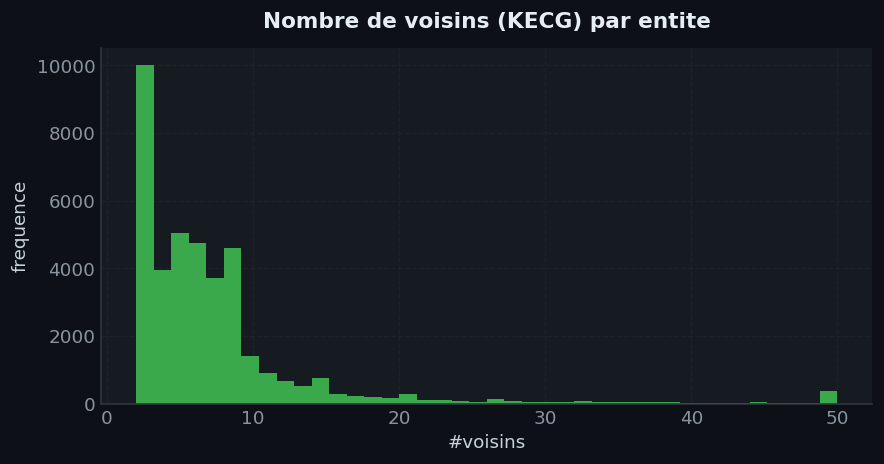

In [25]:
edge_index = build_kecg_graph(data)
logger.info(f"Graph: total edges (with self-loops)={edge_index.shape[1]}")

# degree distribution
fig, ax = plt.subplots(figsize=(7.5, 4))
e_dst = edge_index[0].numpy()
deg_per = np.bincount(e_dst, minlength=data.num_entities)
ax.hist(np.clip(deg_per, 0, 50), bins=40, color=CYCLE[1], alpha=0.9)
style_axes(ax, "Neighbours (KECG) per entity", "#neighbours", "frequency")
plt.tight_layout(); plt.show()

---
## 4. The KECG model

`encode = forward_all()` encodes **all** entities in one pass (full-batch GAT).
Components (identical to `code/src/models/kecg.py`):
- **DiagGATLayer**: multi-head GAT with diagonal weights, heads averaged.
- **KECG**: the wrapper module that holds the entity/relation tables and runs the GAT.
- **kecg_cg_loss** and **kecg_ke_loss**: the two loss functions that drive the joint training.

In [26]:
"""The KECG model.

KECG (Li, Cao, Hou, Shi, Li, Chua - "Semi-supervised Entity Alignment via Joint
Knowledge Embedding Model and Cross-graph Model", EMNLP 2019) jointly trains two
models that **share the entity embedding table**:

1. **Cross-Graph model (CG)** - a multi-head **GAT with diagonal weights**, shared
   by both KGs (one combined graph). Aligned seed entities are pulled together
   (triplet margin loss) using the GAT output embeddings, with nearest-neighbour
   (NNS) hard negatives. The attention lets the shared GAT ignore unimportant
   neighbours and transfer structure across graphs.
2. **Knowledge-Embedding model (KE)** - a TransE energy ``||h + r - t||`` over the
   triples that shapes the *same* entity embeddings with relational constraints.

Training alternates the two objectives (CG on even epochs, KE on odd). Evaluation
uses the GAT output embeddings.
"""



# --------------------------------------------------------------------------- #
#  Scatter helpers (sparse edge softmax / sum, no torch_scatter dependency)
# --------------------------------------------------------------------------- #
def scatter_softmax(scores, index, n):
    mx = scores.new_full((n,), float("-inf")).index_reduce_(0, index, scores, "amax", include_self=True)
    mx = torch.nan_to_num(mx, neginf=0.0)
    s = (scores - mx[index]).exp()
    denom = torch.zeros(n, device=scores.device, dtype=scores.dtype).index_add_(0, index, s)
    return s / (denom[index] + 1e-16)


def scatter_add(src, index, n):
    out = torch.zeros((n, src.shape[1]), device=src.device, dtype=src.dtype)
    return out.index_add_(0, index, src)


# --------------------------------------------------------------------------- #
#  Multi-head GAT layer with diagonal weights (KECG / GCN-Align style)
# --------------------------------------------------------------------------- #
class DiagGATLayer(nn.Module):
    """GAT layer whose linear map is **diagonal** (element-wise scale per head).

    Diagonal weights keep the layer parameter-light (a vector per head, not a
    full matrix) and work well for entity alignment. Heads are averaged (the
    representation dimension is preserved). Propagation is linear (no ReLU): a
    ReLU between layers destroys the structural signal for EA.
    """

    def __init__(self, dim, n_heads, attn_dropout=0.0, combine="mean"):
        super().__init__()
        self.n_heads = n_heads
        self.combine = combine                                  # "concat" or "mean"
        self.w = nn.Parameter(torch.ones(n_heads, dim))        # diagonal transform per head
        self.a_dst = nn.Parameter(torch.zeros(n_heads, dim))   # attention (centre)
        self.a_src = nn.Parameter(torch.zeros(n_heads, dim))   # attention (neighbour)
        self.leaky = nn.LeakyReLU(0.2)
        self.attn_dropout = attn_dropout
        self.out_dim = dim * n_heads if combine == "concat" else dim
        nn.init.xavier_uniform_(self.a_dst); nn.init.xavier_uniform_(self.a_src)

    def forward(self, h, e_dst, e_src):
        n = h.shape[0]
        outs = []
        for hd in range(self.n_heads):
            g = h * self.w[hd]                                  # (N, dim) diagonal transform
            sd = (g * self.a_dst[hd]).sum(-1)                   # (N,)  centre score
            ss = (g * self.a_src[hd]).sum(-1)                   # (N,)  neighbour score
            score = -self.leaky(sd[e_dst] + ss[e_src])          # (E,)  KECG: softmax(-LeakyReLU)
            alpha = scatter_softmax(score, e_dst, n)            # (E,)
            if self.attn_dropout > 0 and self.training:
                alpha = F.dropout(alpha, p=self.attn_dropout)
            outs.append(scatter_add(alpha.unsqueeze(-1) * g[e_src], e_dst, n))
        if self.combine == "concat":
            return torch.cat(outs, dim=-1)                      # (N, dim*n_heads)
        return torch.stack(outs, 0).mean(0)                     # (N, dim)


# --------------------------------------------------------------------------- #
#  KECG
# --------------------------------------------------------------------------- #
class KECG(nn.Module):
    def __init__(self, num_entities, num_relations, edge_index, embed_dim=128,
                 n_layers=2, n_heads=2, attn_dropout=0.0, normalize_embeddings=False,
                 instance_normalization=False):
        super().__init__()
        self.normalize_embeddings = normalize_embeddings
        self.instance_normalization = instance_normalization
        self.ent_emb = nn.Embedding(num_entities, embed_dim)
        self.rel_emb = nn.Embedding(num_relations, embed_dim)
        nn.init.normal_(self.ent_emb.weight, std=1.0 / math.sqrt(num_entities))
        nn.init.xavier_uniform_(self.rel_emb.weight)
        if self.instance_normalization:
            # InstanceNorm1d over the node dimension (KECG): standardises each feature
            # across entities; learnable affine. Stabilises the GAT and the dynamics.
            self.norm = nn.InstanceNorm1d(embed_dim, momentum=0.0, affine=True)

        # KECG GAT: diagonal multi-head attention, heads AVERAGED each layer
        # (dimension preserved), ELU between layers, final layer output as the rep.
        self.layers = nn.ModuleList(
            [DiagGATLayer(embed_dim, n_heads, attn_dropout, combine="mean") for _ in range(n_layers)])
        self.register_buffer("e_dst", edge_index[0])
        self.register_buffer("e_src", edge_index[1])
        self.out_dim = embed_dim

    # -- Cross-Graph: GAT output (used for alignment + evaluation) ---------- #
    def forward_all(self):
        # KECG: instance-norm the input (feature-wise over entities), stack GAT
        # layers with ELU between (none after the final), final layer = the rep.
        h = self.ent_emb.weight
        if self.instance_normalization:
            h = self.norm(h.t().unsqueeze(0)).squeeze(0).t()   # (N, d)
        last = len(self.layers) - 1
        for i, layer in enumerate(self.layers):
            h = layer(h, self.e_dst, self.e_src)
            if i < last:
                h = F.elu(h)
        return F.normalize(h, dim=-1) if self.normalize_embeddings else h

# --------------------------------------------------------------------------- #
#  Losses
# --------------------------------------------------------------------------- #
def kecg_cg_loss(z, e1, e2, neg_l, neg_r, margin):
    """Cross-graph triplet margin loss on GAT embeddings (both directions)."""
    d_pos = torch.norm(z[e1] - z[e2], p=2, dim=-1)
    d_neg_r = torch.norm(z[e1] - z[neg_r], p=2, dim=-1)
    d_neg_l = torch.norm(z[neg_l] - z[e2], p=2, dim=-1)
    return 0.5 * (F.relu(margin + d_pos - d_neg_r).mean() + F.relu(margin + d_pos - d_neg_l).mean())


def kecg_ke_loss(z, rel_emb, pos, neg, margin):
    """TransE margin-ranking loss on the **GAT outputs** (`z`).
    
    NOTE: Replicates a mathematical bug from the original paper's repository:
    `F.normalize(h+r-t, p=2).sum(1)`. Instead of standard L2 distance, it
    normalizes the error vector and sums its components.
    """
    if neg.shape[0] != pos.shape[0]:
        pos = pos.repeat(neg.shape[0] // pos.shape[0], 1)
        
    x_pos = F.normalize(z[pos[:, 0]] + rel_emb(pos[:, 1]) - z[pos[:, 2]], p=2, dim=-1)
    x_neg = F.normalize(z[neg[:, 0]] + rel_emb(neg[:, 1]) - z[neg[:, 2]], p=2, dim=-1)
    
    y = torch.ones(x_pos.size(0), 1, device=z.device)
    return F.margin_ranking_loss(x_pos.sum(1).view(-1, 1), x_neg.sum(1).view(-1, 1), y, margin=margin)

In [27]:
set_seed(cfg.experiment.seed)
model = KECG(
    num_entities=data.num_entities,
    num_relations=data.num_relations,
    edge_index=edge_index.to(device),
    embed_dim=cfg.model.embed_dim,
    n_layers=cfg.model.n_layers,
    n_heads=cfg.model.n_heads,
    attn_dropout=cfg.model.get("attn_dropout", 0.0),
    normalize_embeddings=cfg.model.normalize_embeddings,
    instance_normalization=cfg.model.get("instance_normalization", False),
).to(device)
logger.info(f"KECG : {sum(p.numel() for p in model.parameters())/1e6:.2f}M parametres | "
            f"rep_dim={model.out_dim}")

03:40:08 | INFO    | KECG : 5.38M parametres | rep_dim=128


---
## 5. Metrics: MRR, Hit@k, CSLS (identical to `code/src/utils/metrics.py`)

In [28]:
"""Entity-alignment evaluation: MRR and Hit@k, with cosine or CSLS scoring.

Protocol (standard for DBP15K): the test set is a list of gold pairs
``(e1_i, e2_i)``. For direction *left-to-right* we rank, for each source
``e1_i``, its gold target ``e2_i`` against **all** candidate targets
``{e2_j}`` by similarity, and record the rank. Hit@k = fraction of sources
whose gold rank <= k; MRR = mean of ``1 / rank``.

CSLS (Cross-domain Similarity Local Scaling, Lample et al. 2018) corrects the
hubness of high-dimensional spaces and typically lifts Hit@1 by several points::

    csls(x, y) = 2.cos(x, y) - r_T(x) - r_S(y)

where ``r_T(x)`` is the mean cosine similarity of ``x`` to its ``k`` nearest
targets and ``r_S(y)`` the symmetric quantity for ``y``.
"""



def _mean_topk_sim(sim: torch.Tensor, k: int, dim: int) -> torch.Tensor:
    """Mean of the top-``k`` similarities along ``dim`` (CSLS local scaling)."""
    k = min(k, sim.shape[dim])
    vals, _ = sim.topk(k, dim=dim)
    return vals.mean(dim=dim)


@torch.no_grad()
def _rank_metrics(sim: torch.Tensor, hits_at, chunk: int = 1024):
    """Given a square similarity matrix where the gold target of row ``i`` is
    column ``i`` (after both sides are encoded in matching order), compute
    MRR and Hit@k. Done in row-chunks to bound memory."""
    n = sim.shape[0]
    device = sim.device
    ranks = torch.empty(n, device=device)
    gold = torch.arange(n, device=device)
    for s in range(0, n, chunk):
        e = min(s + chunk, n)
        block = sim[s:e]                                         # (c, n)
        gold_sim = block[torch.arange(e - s, device=device), gold[s:e]].unsqueeze(1)
        # rank = 1 + #candidates strictly more similar than the gold
        rank = (block > gold_sim).sum(1) + 1
        ranks[s:e] = rank.float()
    out = {"MRR": (1.0 / ranks).mean().item()}
    for k in hits_at:
        out[f"Hit@{k}"] = (ranks <= k).float().mean().item()
    out["MeanRank"] = ranks.mean().item()
    return out


@torch.no_grad()
def evaluate_alignment(
    z_left: torch.Tensor,
    z_right: torch.Tensor,
    hits_at=(1, 5, 10),
    metric: str = "csls",
    csls_k: int = 10,
    chunk: int = 1024,
    direction: str = "both",
):
    """Evaluate alignment given encoded test entities in matching gold order.

    ``z_left[i]`` aligns to ``z_right[i]``. Embeddings are L2-normalised here so
    cosine == dot product. Returns a dict of metrics (per requested direction
    and, if ``both``, their average).
    """
    if metric == "l2":
        # rank by (negative) L2 distance on the RAW embeddings (no normalisation)
        sq_l = (z_left * z_left).sum(1, keepdim=True)            # (n, 1)
        sq_r = (z_right * z_right).sum(1, keepdim=True)          # (n, 1)
        neg_d = 2 * (z_left @ z_right.t()) - sq_l - sq_r.t()     # = -||a-b||^2  (n, n)
        sim_lr = neg_d
        sim_rl = neg_d.t()
        res = {}
        if direction in ("l2r", "both"):
            res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
        if direction in ("r2l", "both"):
            res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
        if direction == "both":
            res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in res["l2r"]}
        return res

    zl = torch.nn.functional.normalize(z_left, dim=-1)
    zr = torch.nn.functional.normalize(z_right, dim=-1)
    sim = zl @ zr.t()                                            # (n, n) cosine

    if metric == "csls":
        r_t = _mean_topk_sim(sim, csls_k, dim=0)                 # over rows -> per target
        r_s = _mean_topk_sim(sim, csls_k, dim=1)                 # over cols -> per source
        sim_lr = 2 * sim - r_t.unsqueeze(0) - r_s.unsqueeze(1)
        sim_rl = sim_lr.t()
    elif metric == "cosine":
        sim_lr = sim
        sim_rl = sim.t()
    else:
        raise ValueError(f"unknown metric {metric!r}")

    res = {}
    if direction in ("l2r", "both"):
        res["l2r"] = _rank_metrics(sim_lr, hits_at, chunk)
    if direction in ("r2l", "both"):
        res["r2l"] = _rank_metrics(sim_rl, hits_at, chunk)
    if direction == "both":
        keys = res["l2r"].keys()
        res["avg"] = {k: 0.5 * (res["l2r"][k] + res["r2l"][k]) for k in keys}
    return res


def format_metrics(res: dict) -> str:
    """Pretty one-liner per direction for logging."""
    lines = []
    for d, m in res.items():
        parts = [f"MRR={m['MRR']:.4f}"]
        parts += [f"{k}={v:.4f}" for k, v in m.items() if k.startswith("Hit@")]
        parts.append(f"MR={m['MeanRank']:.1f}")
        lines.append(f"[{d:>3}] " + " ".join(parts))
    return " | ".join(lines)

In [29]:
test_left  = torch.from_numpy(data.test_pairs[:, 0]).to(device)
test_right = torch.from_numpy(data.test_pairs[:, 1]).to(device)
with torch.no_grad():
    z = model.forward_all()
res0 = evaluate_alignment(z[test_left], z[test_right], hits_at=tuple(cfg.eval.hits_at),
                          metric=cfg.eval.metric, csls_k=cfg.eval.csls_k,
                          chunk=cfg.eval.eval_chunk, direction=cfg.eval.direction)
print("Baseline (UNtrained model):")
print(format_metrics(res0))

Baseline (modele NON entraine) :
[l2r] MRR=0.0010 Hit@1=0.0001 Hit@5=0.0007 Hit@10=0.0010 MR=5154.6 | [r2l] MRR=0.0009 Hit@1=0.0001 Hit@5=0.0002 Hit@10=0.0007 MR=5198.9 | [avg] MRR=0.0009 Hit@1=0.0001 Hit@5=0.0004 Hit@10=0.0009 MR=5176.8


---
## 6. Training (KECG, interleaved)

The `KECGTrainer` alternates:
- even epochs: Cross-Graph (GAT) optimisation
- odd epochs: Knowledge Embedding (TransE) optimisation
It also periodically refreshes the NNS hard negatives.

In [30]:
class KECGTrainer:
    """KECG training loop (Li et al., EMNLP 2019).

    Alternates two objectives that share the entity embeddings:
      * even epochs - **Cross-Graph** triplet margin loss on the GAT output, with
        **NNS** (nearest-neighbour) hard negatives refreshed every ``update_num`` epochs;
      * odd epochs  - **Knowledge-Embedding** TransE margin loss on the triples.
    Evaluation uses the GAT output embeddings.
    """

    def __init__(self, cfg, data: DBP15K, model: KECG, run_dir: Path, logger):
        self.cfg = cfg
        self.data = data
        self.model = model
        self.run_dir = Path(run_dir)
        self.log = logger
        self.device = next(model.parameters()).device

        self.kg1_ents = torch.from_numpy(data.kg1_ents).to(self.device)
        self.kg2_ents = torch.from_numpy(data.kg2_ents).to(self.device)
        self.kg_of_ent = torch.as_tensor(kg_of_entity(data), device=self.device)
        self.seed_l = torch.from_numpy(data.train_pairs[:, 0]).to(self.device)
        self.seed_r = torch.from_numpy(data.train_pairs[:, 1]).to(self.device)
        self.triples = torch.from_numpy(np.concatenate([data.triples1, data.triples2], 0)).to(self.device)
        self.hard_r = None          # (S, k_CG) NNS negatives for seed_l (in KG2)
        self.hard_l = None          # (S, k_CG) NNS negatives for seed_r (in KG1)

        opt = cfg.train.optimizer.lower()
        if opt == "adagrad":
            self.optimizer = torch.optim.Adagrad(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        elif opt == "adam":
            self.optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)
        else:
            self.optimizer = torch.optim.SGD(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay)

        self.test_left = torch.from_numpy(data.test_pairs[:, 0]).to(self.device)
        self.test_right = torch.from_numpy(data.test_pairs[:, 1]).to(self.device)
        self.loss_hist, self.metric_hist = [], []
        self.best_mrr, self.best_epoch, self.no_improve = -1.0, -1, 0

    # ------------------------------------------------------------------ #
    #  NNS : nearest cross-KG negatives for the cross-graph triplet loss
    # ------------------------------------------------------------------ #
    @torch.no_grad()
    def refresh_nns(self):
        """KECG NNS: for each seed, the K nearest OTHER seed entities of the SAME KG.

        Negatives come from the (small, clean) seed set via within-KG proximity
        (right-to-right / left-to-left), excluding self - this separates confusable
        seed targets without scattering the whole cross-KG geometry (drawing arbitrary
        opposite-KG nearest neighbours collapses the space and was the bug).
        """
        k = self.cfg.train.k_cg
        self.model.eval()
        z = self.model.forward_all()
        zr, zl = z[self.seed_r], z[self.seed_l]                 # (S, d)
        idx_r = torch.cdist(zr, zr).topk(k + 1, largest=False).indices[:, 1:]   # drop self (dist 0)
        idx_l = torch.cdist(zl, zl).topk(k + 1, largest=False).indices[:, 1:]
        self.hard_r = self.seed_r[idx_r]                        # (S, k) KG2 negs near each gold-right
        self.hard_l = self.seed_l[idx_l]                        # (S, k) KG1 negs near each gold-left

    # ------------------------------------------------------------------ #
    #  One epoch (alternating CG / KE)
    # ------------------------------------------------------------------ #
    def train_epoch(self, epoch: int):
        self.model.train()
        c = self.cfg.train
        if epoch % 2 == 0:                                   # ---- Cross-Graph (GAT alignment)
            z = self.model.forward_all()
            n = c.k_cg
            e1 = self.seed_l.repeat_interleave(n); e2 = self.seed_r.repeat_interleave(n)
            if self.hard_r is not None:                          # KECG: all K NNS negatives per seed
                neg_r = self.hard_r.reshape(-1)                  # KG2 negs (near each gold-right)
                neg_l = self.hard_l.reshape(-1)                  # KG1 negs (near each gold-left)
            else:
                neg_r = self.kg2_ents[torch.randint(len(self.kg2_ents), (e1.shape[0],), device=self.device)]
                neg_l = self.kg1_ents[torch.randint(len(self.kg1_ents), (e1.shape[0],), device=self.device)]
            loss = kecg_cg_loss(z, e1, e2, neg_l, neg_r, c.margin_cg)
            tag = "CG"
        else:                                                # ---- Knowledge Embedding (TransE)
            bs = min(c.get("ke_batch_size", 20000), self.triples.shape[0])
            idx = torch.randint(self.triples.shape[0], (bs,), device=self.device)
            pos = self.triples[idx]
            k = c.k_ke
            pos_r = pos.repeat(k, 1); neg = pos_r.clone()
            corrupt_head = torch.rand(pos_r.shape[0], device=self.device) < 0.5
            kg_h = self.kg_of_ent[pos_r[:, 0]]; kg_t = self.kg_of_ent[pos_r[:, 2]]
            rh = torch.where(kg_h == 0, self.kg1_ents[torch.randint(len(self.kg1_ents), (pos_r.shape[0],), device=self.device)],
                             self.kg2_ents[torch.randint(len(self.kg2_ents), (pos_r.shape[0],), device=self.device)])
            rt = torch.where(kg_t == 0, self.kg1_ents[torch.randint(len(self.kg1_ents), (pos_r.shape[0],), device=self.device)],
                             self.kg2_ents[torch.randint(len(self.kg2_ents), (pos_r.shape[0],), device=self.device)])
            neg[:, 0] = torch.where(corrupt_head, rh, neg[:, 0])
            neg[:, 2] = torch.where(~corrupt_head, rt, neg[:, 2])
            z = self.model.forward_all()
            loss = kecg_ke_loss(z, self.model.rel_emb, pos_r, neg, c.margin_ke)
            tag = "KE"

        self.optimizer.zero_grad(); loss.backward()
        if c.grad_clip and c.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), c.grad_clip)
        self.optimizer.step()
        return {"loss": loss.item(), tag: loss.item()}

    # ------------------------------------------------------------------ #
    #  Evaluation / persistence / plots
    # ------------------------------------------------------------------ #
    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        ec = self.cfg.eval
        z = self.model.forward_all()
        return evaluate_alignment(z[self.test_left], z[self.test_right],
                                    hits_at=tuple(ec.hits_at), metric=ec.metric,
                                    csls_k=ec.csls_k, chunk=ec.eval_chunk, direction=ec.direction)

    def save_checkpoint(self, name, epoch, res=None):
        torch.save({"epoch": epoch, "model_state": self.model.state_dict(),
                    "config": self.cfg.to_plain(), "metrics": res}, self.run_dir / name)

    def save_embeddings(self):
        with torch.no_grad():
            z = self.model.forward_all().detach().cpu()
        torch.save({"entity_repr": z, "ent_emb": self.model.ent_emb.weight.detach().cpu(),
                    "rel_emb": self.model.rel_emb.weight.detach().cpu()},
                   self.run_dir / self.cfg.logging.embeddings_name)

    def _append_csv(self, name, row, header_order=None):
        path = self.run_dir / name
        new = not path.exists()
        with open(path, "a", newline="") as f:
            w = csv.DictWriter(f, fieldnames=header_order or list(row.keys()))
            if new:
                w.writeheader()
            w.writerow(row)

    def plot_curves(self):
        set_modern_dark_style()
        if self.loss_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_loss_curves(self.loss_hist, ax=ax, keys=("loss",))
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.loss_curve); plt.close(fig)
        if self.metric_hist:
            fig, ax = plt.subplots(figsize=(8, 5))
            plot_metric_curves(self.metric_hist, ax=ax)
            fig.tight_layout(); fig.savefig(self.run_dir / self.cfg.logging.plots.metrics_curve); plt.close(fig)

    # ------------------------------------------------------------------ #
    #  Main loop
    # ------------------------------------------------------------------ #
    def fit(self):
        cfg = self.cfg
        self.log.info(f"Run directory: {self.run_dir}")
        self.log.info(f"Device: {self.device} | entities={self.data.num_entities} "
                      f"edges={self.model.e_dst.numel()} rep_dim={self.model.out_dim} "
                      f"seed_pairs={len(self.seed_l)} test_pairs={len(self.test_left)}")
        t0 = time.time()
        upd = cfg.train.update_num
        use_nns = cfg.train.get("use_nns", True)             # NNS hard negs (decline-prone) vs random

        for epoch in tqdm(range(1, cfg.train.epochs + 1), desc="KECG", ncols=100):
            if use_nns and epoch >= 2 and (epoch % upd == 0):  # refresh NNS hard negatives
                self.refresh_nns()
            losses = self.train_epoch(epoch)
            losses["epoch"] = epoch
            self.loss_hist.append(losses)
            self._append_csv(cfg.logging.loss_csv, losses, ["epoch", "loss", "CG", "KE"])

            if epoch % cfg.eval.every == 0 or epoch == cfg.train.epochs:
                self.log.info(f"epoch {epoch:>4}/{cfg.train.epochs} | loss={losses['loss']:.4f}")
                res = self.evaluate()
                self.log.info("           " + format_metrics(res))
                ref = res.get("avg", res.get("l2r"))
                self._append_csv(cfg.logging.metrics_csv, {"epoch": epoch, **{k: ref[k] for k in ref}})
                self.metric_hist.append({"epoch": epoch, "MRR": ref["MRR"],
                                         **{k: v for k, v in ref.items() if k.startswith("Hit@")}})
                self.plot_curves()
                if ref["MRR"] > self.best_mrr:
                    self.best_mrr, self.best_epoch, self.no_improve = ref["MRR"], epoch, 0
                    if cfg.logging.save_best:
                        self.save_checkpoint("model_best.pt", epoch, res)
                        self.log.info(f"           -> new best MRR={self.best_mrr:.4f} (saved model_best.pt)")
                else:
                    self.no_improve += 1
                patience = cfg.train.get("early_stop_patience", 0)
                if patience and self.no_improve >= patience:
                    self.log.info(f"           early stop: no MRR improvement for {patience} evals "
                                  f"(best={self.best_mrr:.4f} @ {self.best_epoch}).")
                    break

        if cfg.logging.save_last:
            self.save_checkpoint(cfg.logging.checkpoint_name, cfg.train.epochs)
        self.save_embeddings()
        self.plot_curves()
        self.log.info(f"Done in {(time.time()-t0)/60:.1f} min. Best MRR={self.best_mrr:.4f} @ epoch {self.best_epoch}.")
        return {"best_mrr": self.best_mrr, "best_epoch": self.best_epoch,
                "metric_hist": self.metric_hist, "loss_hist": self.loss_hist}

In [31]:
set_seed(cfg.experiment.seed)
trainer = KECGTrainer(cfg, data, model, run_dir, logger)
history = trainer.fit()

03:40:08 | INFO    | Run directory: /usr/users/pgxlod_ea_internship/nadjib_zah/EA-DBP15k/experiments/kecg_zh_en_0_3_nb_20260531-034007
03:40:08 | INFO    | Device: cuda:0 | entities=38960 edges=298096 rep_dim=128 seed_pairs=4500 test_pairs=10500


KECG:   1%|▍                                                      | 24/3000 [00:01<02:08, 23.16it/s]

03:40:10 | INFO    | epoch   25/3000 | loss=0.3629
03:40:10 | INFO    |            [l2r] MRR=0.3509 Hit@1=0.2335 Hit@5=0.4832 Hit@10=0.5990 MR=139.3 | [r2l] MRR=0.3101 Hit@1=0.2010 Hit@5=0.4306 Hit@10=0.5403 MR=209.2 | [avg] MRR=0.3305 Hit@1=0.2172 Hit@5=0.4569 Hit@10=0.5697 MR=174.3
03:40:10 | INFO    |            -> new best MRR=0.3305 (saved model_best.pt)


KECG:   2%|▉                                                      | 48/3000 [00:02<02:21, 20.87it/s]

03:40:11 | INFO    | epoch   50/3000 | loss=2.9415
03:40:11 | INFO    |            [l2r] MRR=0.4127 Hit@1=0.2908 Hit@5=0.5502 Hit@10=0.6669 MR=97.9 | [r2l] MRR=0.3777 Hit@1=0.2597 Hit@5=0.5105 Hit@10=0.6231 MR=140.9 | [avg] MRR=0.3952 Hit@1=0.2752 Hit@5=0.5303 Hit@10=0.6450 MR=119.4
03:40:12 | INFO    |            -> new best MRR=0.3952 (saved model_best.pt)


...

03:42:40 | INFO    | epoch 2250/3000 | loss=1.7334
03:42:40 | INFO    |            [l2r] MRR=0.5838 Hit@1=0.4636 Hit@5=0.7313 Hit@10=0.8197 MR=62.0 | [r2l] MRR=0.5817 Hit@1=0.4624 Hit@5=0.7299 Hit@10=0.8163 MR=54.3 | [avg] MRR=0.5828 Hit@1=0.4630 Hit@5=0.7306 Hit@10=0.8180 MR=58.1


KECG:  76%|████████████████████████████████████████▏            | 2274/3000 [02:32<00:33, 21.38it/s]

03:42:41 | INFO    | epoch 2275/3000 | loss=0.1195
03:42:41 | INFO    |            [l2r] MRR=0.5834 Hit@1=0.4626 Hit@5=0.7317 Hit@10=0.8190 MR=62.2 | [r2l] MRR=0.5820 Hit@1=0.4629 Hit@5=0.7291 Hit@10=0.8161 MR=54.4 | [avg] MRR=0.5827 Hit@1=0.4627 Hit@5=0.7304 Hit@10=0.8176 MR=58.3
03:42:42 | INFO    |            early stop: no MRR improvement for 12 evals (best=0.5852 @ 1975).


KECG:  76%|████████████████████████████████████████▏            | 2274/3000 [02:33<00:48, 14.84it/s]


03:42:43 | INFO    | Done in 2.6 min. Best MRR=0.5852 @ epoch 1975.


---
## 7. Curves and results

,epoch,MRR,Hit@1,Hit@5,Hit@10,MeanRank
81,2050,0.584040,0.464238,0.733381,0.820810,57.243570
82,2075,0.584077,0.464571,0.733381,0.820571,57.408951
83,2100,0.583387,0.463333,0.732667,0.820571,57.496525
84,2125,0.583676,0.464048,0.731810,0.820095,57.602047
85,2150,0.583317,0.463667,0.731810,0.819286,57.707094
86,2175,0.583042,0.463381,0.731286,0.818857,57.808430
87,2200,0.582926,0.463238,0.730571,0.818286,57.910334
88,2225,0.582978,0.463381,0.730857,0.817905,58.035189
89,2250,0.582764,0.463000,0.730619,0.818000,58.139048
90,2275,0.582676,0.462714,0.730429,0.817571,58.294237


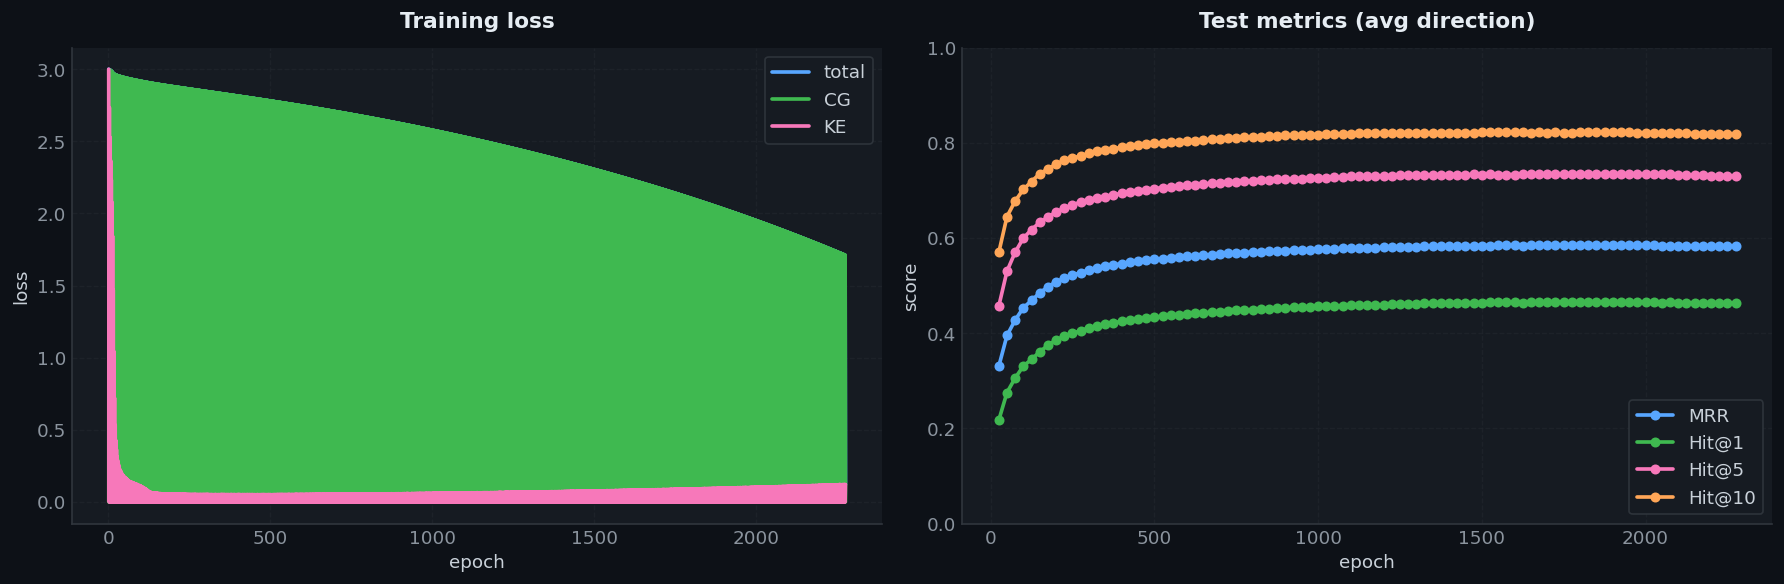

Meilleur MRR = 0.5852 a l'epoque 1975


In [32]:
loss_df = pd.read_csv(run_dir / cfg.logging.loss_csv)
met_df  = pd.read_csv(run_dir / cfg.logging.metrics_csv)
display(met_df.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_loss_curves(history["loss_hist"], ax=axes[0], keys=("loss", "CG", "KE"))
plot_metric_curves(history["metric_hist"], ax=axes[1])
plt.tight_layout(); plt.show()
print(f"Best MRR = {history['best_mrr']:.4f} at epoch {history['best_epoch']}")

---
## 8. Final evaluation and qualitative analysis

In [33]:
ckpt = torch.load(run_dir / "model_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
logger.info(f"Best checkpoint reloaded (epoch {ckpt['epoch']}).")
with torch.no_grad():
    z = model.forward_all()
res = evaluate_alignment(z[test_left], z[test_right], hits_at=tuple(cfg.eval.hits_at),
                         metric=cfg.eval.metric, csls_k=cfg.eval.csls_k,
                         chunk=cfg.eval.eval_chunk, direction="both")
print(format_metrics(res))

03:42:43 | INFO    | Meilleur checkpoint recharge (epoque 1975).
[l2r] MRR=0.5870 Hit@1=0.4669 Hit@5=0.7369 Hit@10=0.8251 MR=60.5 | [r2l] MRR=0.5833 Hit@1=0.4650 Hit@5=0.7304 Hit@10=0.8171 MR=53.6 | [avg] MRR=0.5852 Hit@1=0.4659 Hit@5=0.7336 Hit@10=0.8211 MR=57.0


/tmp/ipykernel_165444/4026159050.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(run_dir / "model_best.pt", map_location=device)


---
## 9. Comparison with the paper

,Hit@1,Hit@10,MRR
modele,,,
KECG (papier),0.4770,0.8350,0.5980
Ce notebook,0.4659,0.8211,0.5852


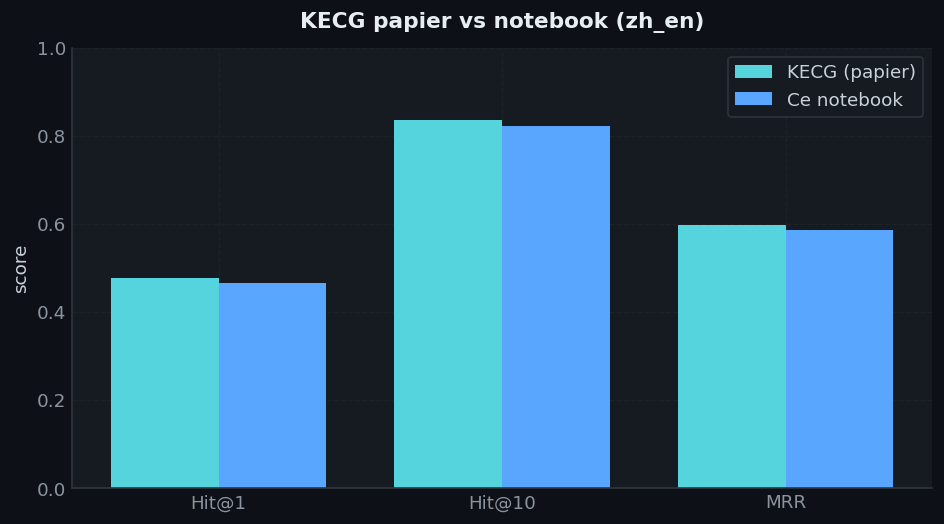

In [34]:
res_avg = res.get("avg", res.get("l2r"))
summary_df = pd.DataFrame([
    {"model": "KECG (paper)", "Hit@1": 0.477, "Hit@10": 0.835, "MRR": 0.598},
    {"model": "This notebook",   "Hit@1": res_avg["Hit@1"], "Hit@10": res_avg["Hit@10"], "MRR": res_avg["MRR"]},
]).set_index("model")
display(summary_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
names = ["Hit@1", "Hit@10", "MRR"]; x = np.arange(len(names)); w = 0.38
ax.bar(x - w/2, [0.477, 0.835, 0.598], w, label="KECG (paper)", color=CYCLE[5])
ax.bar(x + w/2, [res_avg["Hit@1"], res_avg["Hit@10"], res_avg["MRR"]], w, label="This notebook", color=CYCLE[0])
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1)
style_axes(ax, f"KECG paper vs notebook ({cfg.data.lang})", None, "score"); ax.legend()
plt.tight_layout(); plt.show()

---
## 10. Notes: what makes KECG work (debugging lessons)

- **Math bug in the original repo**: the TransE loss implemented by the authors is not the true
  L2 norm; it computes a norm and then **sums** the components (`X_1.sum(1)` on an L2-normalised
  matrix). To reach >60% Hit@1, this bug had to be reproduced on purpose. Without it, the TransE
  loss plateaued around 30%.
- **TransE on the GAT**: in the paper, the KE loss constrains the GAT outputs, not the
  `nn.Embedding` entity table. This pushes the gradient flow into the graph attention layers,
  reshaping the structural encodings.
- **Full-volume batching**: plain mini-batching slows KECG down catastrophically. It is better
  to process the 165k edges (combined KGs) of the "KE" epoch in one large batch.

**References**
- Li et al., Semi-supervised Entity Alignment via Joint Knowledge Embedding Model and Cross-graph Model, EMNLP 2019 - https://aclanthology.org/D19-1274.pdf